In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import json
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df_movies = pd.read_csv('archive1/archive/movies_metadata.csv', sep=',', na_values=[''], quotechar='"')
df_ratings = pd.read_csv('archive1/archive/ratings_small.csv')

def safe_parse(val):
    if pd.isna(val) or val == '' or val == '[]' or val == '{}':
        return None
    try:
        return ast.literal_eval(val)
    except:
        try:
            return json.loads(val)
        except:
            return None

df_movies['id'] = pd.to_numeric(df_movies['id'], errors='coerce')
df_movies = df_movies.dropna(subset=['id']).copy()
df_movies['id'] = df_movies['id'].astype(int)

df_ratings['movieId'] = pd.to_numeric(df_ratings['movieId'], errors='coerce')
df_ratings = df_ratings.dropna(subset=['movieId']).copy()
df_ratings['movieId'] = df_ratings['movieId'].astype(int)

valid_movie_ids = df_ratings['movieId'].unique()
df_movies = df_movies[df_movies['id'].isin(valid_movie_ids)].copy()

df_movies['belongs_to_collection_parsed'] = df_movies['belongs_to_collection'].apply(safe_parse)
df_movies['genres_parsed'] = df_movies['genres'].apply(safe_parse)
df_movies['has_collection'] = df_movies['belongs_to_collection_parsed'].apply(
    lambda x: 1 if isinstance(x, dict) and x.get('name') else 0
)
df_movies['genre_list'] = df_movies['genres_parsed'].apply(
    lambda x: [g['name'] for g in x] if isinstance(x, list) else []
)
mlb_genres = MultiLabelBinarizer()
genres_onehot = mlb_genres.fit_transform(df_movies['genre_list'])
genres_df = pd.DataFrame(genres_onehot, columns=mlb_genres.classes_, index=df_movies.index)

df_movies['production_companies_parsed'] = df_movies['production_companies'].apply(safe_parse)
def extract_company_names(x):
    if isinstance(x, list):
        return [comp.get('name', '') for comp in x if isinstance(comp, dict) and comp.get('name')]
    return []
df_movies['company_list'] = df_movies['production_companies_parsed'].apply(extract_company_names)
all_companies = df_movies['company_list'].explode()
top_companies = all_companies.value_counts().head(20).index.tolist()
def keep_top_companies(companies):
    return [c for c in companies if c in top_companies] or ['other']
df_movies['company_list_top'] = df_movies['company_list'].apply(keep_top_companies)
mlb_companies = MultiLabelBinarizer()
companies_onehot = mlb_companies.fit_transform(df_movies['company_list_top'])
companies_df = pd.DataFrame(companies_onehot, columns=mlb_companies.classes_, index=df_movies.index)

df_movies['production_countries_parsed'] = df_movies['production_countries'].apply(safe_parse)
def extract_country_names(x):
    if isinstance(x, list):
        return [cnt.get('name', '') for cnt in x if isinstance(cnt, dict) and cnt.get('name')]
    return []
df_movies['country_list'] = df_movies['production_countries_parsed'].apply(extract_country_names)
all_countries = df_movies['country_list'].explode()
top_countries = all_countries.value_counts().head(10).index.tolist()
def keep_top_countries(countries):
    return [c for c in countries if c in top_countries] or ['other']
df_movies['country_list_top'] = df_movies['country_list'].apply(keep_top_countries)
mlb_countries = MultiLabelBinarizer()
countries_onehot = mlb_countries.fit_transform(df_movies['country_list_top'])
countries_df = pd.DataFrame(countries_onehot, columns=mlb_countries.classes_, index=df_movies.index)

df_movies['original_language'] = df_movies['original_language'].fillna('unknown')
top_languages = df_movies['original_language'].value_counts().head(10).index.tolist()
df_movies['language_top'] = df_movies['original_language'].apply(
    lambda x: x if x in top_languages else 'other'
)
lang_onehot = pd.get_dummies(df_movies['language_top'], prefix='lang').astype(int)

df_movies['adult'] = df_movies['adult'].apply(lambda x: 1 if str(x).lower() == 'true' else 0)
df_movies['release_date'] = pd.to_datetime(df_movies['release_date'], errors='coerce')
df_movies['release_year'] = df_movies['release_date'].dt.year.fillna(0).astype(int)
df_movies['runtime'] = pd.to_numeric(df_movies['runtime'], errors='coerce').fillna(0)
df_movies['popularity'] = pd.to_numeric(df_movies['popularity'], errors='coerce').fillna(0)
df_movies['budget'] = pd.to_numeric(df_movies['budget'], errors='coerce').fillna(0)
df_movies['revenue'] = pd.to_numeric(df_movies['revenue'], errors='coerce').fillna(0)

df_movies['tagline'] = df_movies['tagline'].fillna('')
df_movies['full_text'] = df_movies['overview'].fillna('') + ' ' + df_movies['tagline']

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df_movies['full_text'])

numeric_cols = ['has_collection', 'adult', 'vote_average', 'vote_count',
                'runtime', 'release_year', 'popularity', 'budget', 'revenue']
numeric_cols = [col for col in numeric_cols if col in df_movies.columns]

dense_features = pd.concat([
    df_movies[numeric_cols].reset_index(drop=True),
    genres_df.reset_index(drop=True),
    companies_df.reset_index(drop=True),
    countries_df.reset_index(drop=True),
    lang_onehot.reset_index(drop=True)
], axis=1)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19524\3304372824.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_movies = pd.read_csv('archive1/archive/movies_metadata.csv', sep=',', na_values=[''], quotechar='"')


In [3]:
scaler = StandardScaler()
dense_scaled = scaler.fit_transform(dense_features)
dense_sparse = csr_matrix(dense_scaled)
X_combined = hstack([dense_sparse, tfidf_matrix])
print(f"Размерность матрицы признаков фильмов: {X_combined.shape}")

Размерность матрицы признаков фильмов: (2831, 5072)


In [4]:
n_svd_components = 50
svd = TruncatedSVD(n_components=n_svd_components, random_state=42)
X_svd = svd.fit_transform(X_combined)

sample_size = min(5000, X_svd.shape[0])
np.random.seed(42)
sample_idx = np.random.choice(X_svd.shape[0], size=sample_size, replace=False)
X_sample = X_svd[sample_idx]

K_range_movies = range(2, 31)
silhouette_scores_movies = []
best_k_movies = None
best_score_movies = -1

for k in K_range_movies:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_svd)
    labels = km.predict(X_sample)
    score = silhouette_score(X_sample, labels)
    silhouette_scores_movies.append(score)
    if score > best_score_movies:
        best_score_movies = score
        best_k_movies = k

print(f"Оптимальное K для фильмов = {best_k_movies} (силуэт = {best_score_movies:.4f})")

Оптимальное K для фильмов = 30 (силуэт = 0.1853)


In [5]:
kmeans_movies = KMeans(n_clusters=best_k_movies, random_state=42, n_init='auto')
df_movies['movie_cluster'] = kmeans_movies.fit_predict(X_svd)
print("Распределение фильмов по кластерам:")
print(df_movies['movie_cluster'].value_counts().sort_index())

ratings_with_clusters = df_ratings.merge(df_movies[['id', 'movie_cluster']], left_on='movieId', right_on='id', how='inner')

user_movie_cluster_avg = ratings_with_clusters.pivot_table(
    index='userId',
    columns='movie_cluster',
    values='rating',
    aggfunc='mean',
    fill_value=0
)

user_movie_cluster_count = ratings_with_clusters.pivot_table(
    index='userId',
    columns='movie_cluster',
    values='rating',
    aggfunc='count',
    fill_value=0
)

user_total_ratings = ratings_with_clusters.groupby('userId').size().rename('total_ratings')
user_profile = user_movie_cluster_avg.join(user_total_ratings)

user_profile = user_profile[user_profile['total_ratings'] >= 10]

print(f"Количество пользователей после фильтрации: {len(user_profile)}")

Распределение фильмов по кластерам:
movie_cluster
0      53
1     672
2     124
3      27
4      74
5     101
6     110
7      22
8     383
9     252
10     21
11     23
12     34
13     22
14     66
15      1
16    220
17    134
18     71
19     16
20     41
21     49
22     19
23     52
24     95
25     36
26     52
27     23
28      1
29     37
Name: count, dtype: int64
Количество пользователей после фильтрации: 633


In [7]:
user_profile.columns = user_profile.columns.astype(str)

scaler_users = StandardScaler()
X_users_scaled = scaler_users.fit_transform(user_profile)

pca = PCA(n_components=min(30, X_users_scaled.shape[1]), random_state=42)
X_users_pca = pca.fit_transform(X_users_scaled)

sample_size_users = min(5000, X_users_pca.shape[0])
np.random.seed(42)
sample_idx_users = np.random.choice(X_users_pca.shape[0], size=sample_size_users, replace=False)
X_sample_users = X_users_pca[sample_idx_users]

K_range_users = range(2, 21)
silhouette_scores_users = []
best_k_users = None
best_score_users = -1

for k in K_range_users:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_users_pca)
    labels = km.predict(X_sample_users)
    score = silhouette_score(X_sample_users, labels)
    silhouette_scores_users.append(score)
    if score > best_score_users:
        best_score_users = score
        best_k_users = k

print(f"Оптимальное K для пользователей = {best_k_users} (силуэт = {best_score_users:.4f})")

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

Оптимальное K для пользователей = 2 (силуэт = 0.1363)


c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

In [8]:
kmeans_users = KMeans(n_clusters=best_k_users, random_state=42, n_init='auto')
user_profile['user_cluster'] = kmeans_users.fit_predict(X_users_pca)
print("Распределение пользователей по кластерам:")
print(user_profile['user_cluster'].value_counts().sort_index())

Распределение пользователей по кластерам:
user_cluster
0    251
1    382
Name: count, dtype: int64


c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


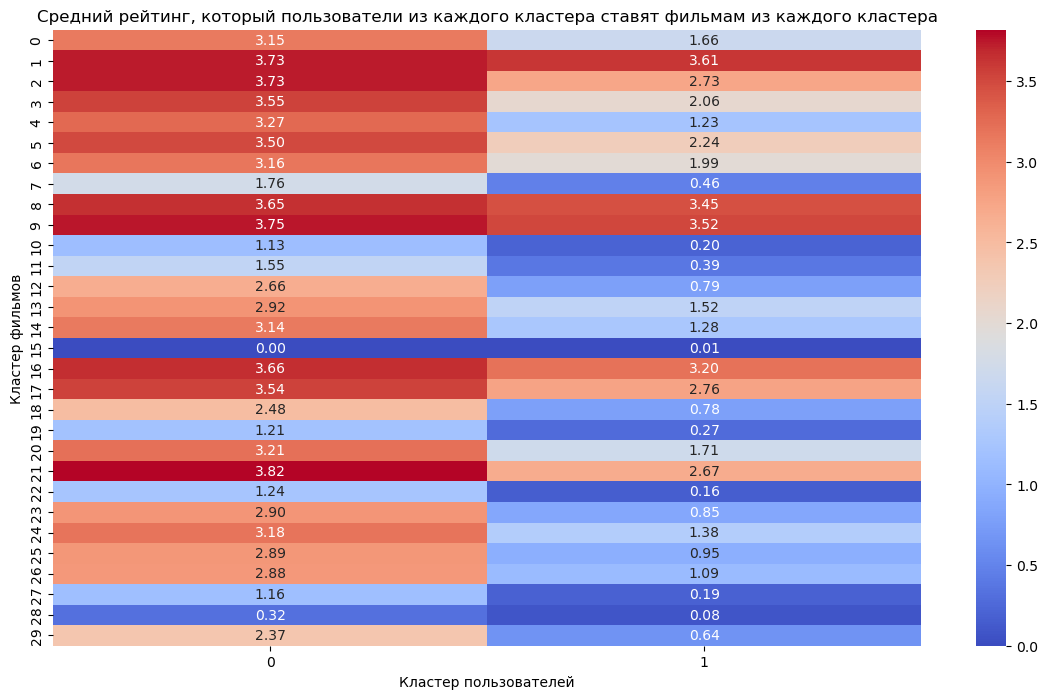

In [9]:
user_cluster_profiles = user_profile.groupby('user_cluster').mean()
user_cluster_profiles = user_cluster_profiles.drop(columns=['total_ratings'], errors='ignore')

plt.figure(figsize=(14, 8))
sns.heatmap(user_cluster_profiles.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.xlabel('Кластер пользователей')
plt.ylabel('Кластер фильмов')
plt.title('Средний рейтинг, который пользователи из каждого кластера ставят фильмам из каждого кластера')
plt.show()

In [10]:
for cluster in user_cluster_profiles.columns:
    top_movie_clusters = user_cluster_profiles[cluster].sort_values(ascending=False).head(5)
    print(f"Кластер пользователей {cluster}: любимые кластеры фильмов (по среднему рейтингу):")
    print(top_movie_clusters)
    print()

Кластер пользователей 0: любимые кластеры фильмов (по среднему рейтингу):
user_cluster
0    3.147532
1    1.658159
Name: 0, dtype: float64

Кластер пользователей 1: любимые кластеры фильмов (по среднему рейтингу):
user_cluster
0    3.730761
1    3.612811
Name: 1, dtype: float64

Кластер пользователей 2: любимые кластеры фильмов (по среднему рейтингу):
user_cluster
0    3.731546
1    2.730261
Name: 2, dtype: float64

Кластер пользователей 3: любимые кластеры фильмов (по среднему рейтингу):
user_cluster
0    3.545127
1    2.056501
Name: 3, dtype: float64

Кластер пользователей 4: любимые кластеры фильмов (по среднему рейтингу):
user_cluster
0    3.270253
1    1.234599
Name: 4, dtype: float64

Кластер пользователей 5: любимые кластеры фильмов (по среднему рейтингу):
user_cluster
0    3.504612
1    2.244322
Name: 5, dtype: float64

Кластер пользователей 6: любимые кластеры фильмов (по среднему рейтингу):
user_cluster
0    3.164827
1    1.985792
Name: 6, dtype: float64

Кластер пользователе